**ΠΑΡΑΔΟΤΕΟ 1**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from simple_markov_chain_lib import markov_chain

Ορίζω συνάρτηση που δέχεται την πιθανότητα p (να κερδίσει ο server έναν πόντο) που επιστρέφει ένα αντικείμενο αλυσίδας Markov.

In [ ]:
def construct_tennis_mc(p):
    markov_table = {
        "0-0": {"15-0": p, "0-15": 1-p},

        "15-0": {"30-0": p, "15-15": 1-p},
        "0-15": {"15-15": p, "0-30": 1-p},

        "30-0": {"40-0": p, "30-15": 1-p},
        "0-30": {"15-30": p, "0-40": 1-p},

        "15-15": {"30-15": p, "15-30": 1-p},

        "40-0": {"win-server": p, "40-15": 1-p},
        "0-40": {"15-40": p, "win-receiver": 1-p},

        "30-15": {"40-15": p, "30-30": 1-p},
        "15-30": {"30-30": p, "15-40": 1-p},

        "40-15": {"win-server": p, "40-30": 1-p},
        "15-40": {"40-30": p, "win-receiver": 1-p},

        "30-30": {"40-30": p, "30-40": 1-p},

        "40-30": {"win-server": p, "deuce": 1-p},
        "30-40": {"deuce": p, "win-receiver": 1-p},

        "deuce": {"ad-server": p, "ad-receiver": 1-p},

        "ad-server": {"win-server": p, "deuce": 1-p},
        "ad-receiver": {"deuce": p, "win-receiver": 1-p},
        # Απορροφητικές καταστάσεις:
        "win-server": {"win-server": 1.0},
        "win-receiver": {"win-receiver": 1.0}
    }
    init_dist = {"0-0": 1.0}

    return markov_chain(markov_table, init_dist)

Επίσης, ορίζω ρουτίνα που εκτελεί το πείραμα N φορές για μια συγκεκριμένη τιμή του p. Σε αντίθεση με το προηγούμενο εργαστήριο  που σταματούσαμε σε σταθερά βήματα, εδώ χρησιμοποιούμε έναν βρόχο που σταματάει όταν η αλυσίδα φτάσει σε κατάσταση απορρόφησης, δηλαδή μέχρι να κερδίσει κάποιος. Επιστρέφω την εκτιμήτρια, πιθανότητα νίκης phat, όπως στο εργαστήριο 2.

In [ ]:
def get_win_prob(p, N):
    mc = construct_tennis_mc(p)
    w = 0
    for i in range(N):
        mc.start()
        while mc.running_state not in ["win-server", "win-receiver"]: # μέχρι να φτάσω σε απορροφητικές καταστάσεις
            mc.move()
        if mc.running_state == "win-server":
            w += 1
    phat = w/N
    return phat

In [ ]:
p_val = np.arange(0.02, 1.0, 0.02)
f_p_est = []
N = 2000
for p in p_val:
    prob_win = get_win_prob(p, N)
    f_p_est.append(prob_win)

Θα χρησιμοποιήσουμε τη βιβλιοθήκη matplotlib για να κάνουμε visualize τη συνάρτηση F(p)

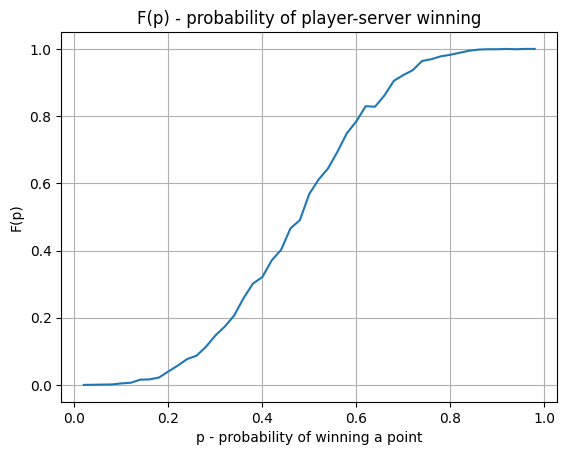

In [ ]:

plt.plot(p_val, f_p_est)
plt.title('F(p) - probability of player-server winning')
plt.xlabel('p - probability of winning a point')
plt.ylabel('F(p)')

plt.grid(True)
plt.show()

Από το παραπάνω αποτέλεσμα, μπορούμε να δούμε ότι η  F(p) έχει σιγμοειδή μορφή. Πιο συγκεκριμένα, παρατηρούμε ότι η F(p)->0 καθώς p->0 και F(p)->1 καθώς p->1, κάτι το οποίο αναδεικνύει  ότι το τελικό αποτέλεσμα εξαρτάται από τη συγκέντρωση ανεξάρτητων επιτυχημένων πόντων. Αξιοσημείωτο είναι το γεγονός ότι για p κοντά στο 0.5, φαίνεται πως η κλίση της συνάρτησης είναι μέγιστη. Ακόμα και μια ελάχιστη αύξηση στο p οδηγεί (όχι αναλογικά) σε μεγαλύτερη αύξηση της πιθανότητας νίκης του αγώνα. Αυτό είναι λογικό επακόλουθο της δομής και των  κανόνων νίκης του αθλήματος, οι οποίοι ενιχύουν ακόμα και την απειροελάχιστη υπεροχή.

**ΠΑΡΑΔΟΤΕΟ 2**

In [ ]:
markov_table = {
    0: {0: 2/5, 1: 1/2, 2: 1/10},
    1: {0: 1/3, 3: 2/3},
    2: {2: 1.},
    3: {0: .5, 1: 1/8, 3: 1/4, 4: 1/8},
    4: {4: 1.}
} # καταστάσεις 2 και 4 απορροφητικές
init_dist = {0: 1.}
mc = markov_chain(markov_table, init_dist)

In [ ]:
import statistics as stat

In [ ]:
M = 35
N_vals = 2**np.arange(4, 12)  # sample sizes
var_s = []

for N in N_vals:
    e_n_est = []
    for i in range(M):
        running_total_steps = 0
        for  j in range(N):
            mc.start()
            while mc.running_state not in [2, 4]:
                mc.move()
            running_total_steps += mc.steps
        e_n_est.append(running_total_steps / N)
    var_s.append(stat.variance(e_n_est))

In [ ]:
var_s

[np.float64(8.779431460084034),
 np.float64(3.8323463760504204),
 np.float64(1.9536009716386555),
 np.float64(0.7949267988445378),
 np.float64(0.469843580742844),
 np.float64(0.26059307451007746),
 np.float64(0.16256994840477695),
 np.float64(0.06679136292273256)]

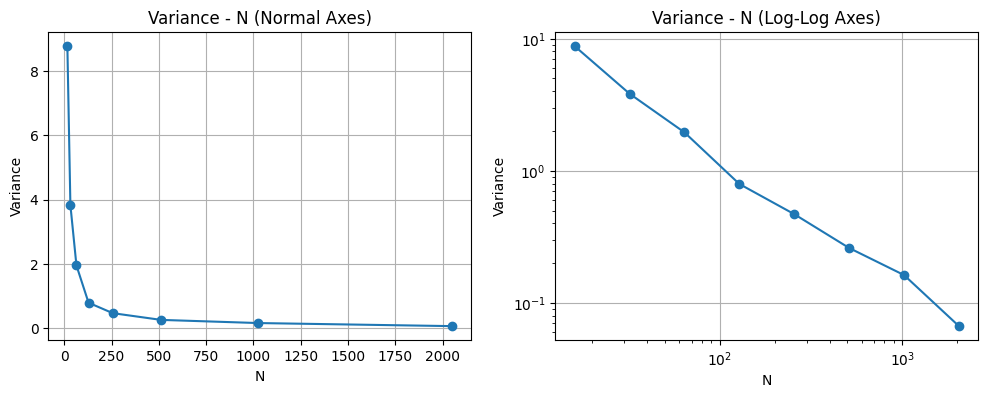

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(N_vals, var_s, 'o-')
ax1.set_xlabel('N')
ax1.set_ylabel('Variance')
ax1.set_title('Variance - N (Normal Axes)')
ax1.grid(True)

ax2.loglog(N_vals, var_s, 'o-')
ax2.set_xlabel('N')
ax2.set_ylabel('Variance')
ax2.set_title('Variance - N (Log-Log Axes)')
ax2.grid(True)

plt.show()

In [ ]:
np.polyfit(np.log2(N_vals), np.log2(var_s), 1)

array([-0.97072821,  6.79951732])

Στο λογαριθμικό διάγραμμα (log-log plot) παρατηρούμε ότι η διασπορά της εκτιμήτριας Var(E_Ν) μειώνεται γραμμικά καθώς αυξάνεται το μέγεθος του δείγματος N, προσεγγίζοντας  ευθεία με κλίση περίπου −1 (συγκεκριμένα −0.97). Αυτό επιβεβαιώνει πειραματικά τη θεωρητική σχέση της διασποράς της Monte Carlo Εκτιμήτριας, Var(E_Ν)​ ~ 1/N, η οποία  μετατρέπεται αν  λογαριθμήσω και τα 2 μέλη στη γραμμική εξίσωση log(Var) ≈ −1⋅log(N)+σταθερά
.

In [ ]:
!jupyter nbconvert --to html lab3_stoch.ipynb

[NbConvertApp] Converting notebook lab3_stoch.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 388176 bytes to lab3_stoch.html
